# M8 | Explainability Notebook

In this notebook, we will do some research to answer our two research questions:
1. Can we predict exam performance using students' quiz results, mock exam results, and behavior within online lessons? (Same as M4)
2. Which features have the greatest influence on our models' predictions of whether a student will pass or fail?

In [60]:
# Import the tables of the data set as dataframes.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter, defaultdict
import dice_ml
from dice_ml.utils import helpers

# Global Variables
ROOT_DIR = Path(os.getcwd()).resolve().parent.parent
DATA_DIR = os.path.join(ROOT_DIR, 'data')
EVENTS_DIR = os.path.join(DATA_DIR, 'events')

# Load data
### Target ###
math_results_df = pd.read_csv(os.path.join(DATA_DIR, 'math_results.csv'))
math_questions_df = pd.read_csv(os.path.join(DATA_DIR, 'math_questions.csv'), header=0)

### Features ###
quiz_results_df = pd.read_csv(os.path.join(DATA_DIR, 'quiz_results.csv'))
pageviews_df = pd.read_csv(os.path.join(DATA_DIR, 'pageviews.csv'))
course_ids_df = pd.read_csv(os.path.join(DATA_DIR, 'course_ids.csv'))
interactions_0_df = pd.read_csv(os.path.join(EVENTS_DIR, '0.csv'))
interactions_m_df = pd.read_csv(os.path.join(EVENTS_DIR, 'm.csv'), dtype={'url': str})
print(interactions_0_df.head())
print(interactions_m_df.head())

   type        timestamp  lastActivity  mouseX  mouseY  scrollY  pageview_id
0     0   13265981803536  2.517226e+14     0.0     0.0      0.0           14
1     0   56215654773548  3.903579e+13  1085.0   917.0      0.0           14
2     0   99234047220289  3.903579e+13  1085.0   917.0      0.0           14
3     0  144863779783627  1.078240e+14   589.0     5.0      0.0           14
4     0  189119122811906  1.078240e+14   589.0     5.0      0.0           14
  type      timestamp mediaType eventType  currentTime  duration  mediaId  \
0    m  1755513879970     vimeo      play        0.000   169.533      3.0   
1    m  1755513880084     vimeo     ended        0.024   169.533      3.0   
2    m  1755513883860     vimeo     pause        3.781   169.533      3.0   
3    m  1755513885464     vimeo     ended       74.022   169.533      3.0   
4    m  1755513886015     vimeo      play       74.022   169.533      3.0   

   pageview_id  url  
0           23  NaN  
1           23  NaN  
2        

## Research Question

**Research question:**
1. Can we predict exam performance using students' quiz results, mock exam results, and behavior within online lessons? (Same as M4)
2. Which features have the greatest influence on our models' predictions of whether a student will pass or fail?

## Data Preprocessing

In this section, we build the target and the features needed to train our model.

### Target preprocessing
The target is built by taking the percentage of correct answers in mock exams available on the platform. Students that have a score of 40% or more are classified as passing (1) others as failing (0). For each student, we merge all their attempt's resulting class (pass or fail) and we take the majority to decide if a student would fail or succeed at the final exam. If the number of fail and pass are the same, we take the last attempt as the deciding class.

In [61]:
# Preprocessing of the target data
# ── CONFIG ───────────────────────────────────────────────────────────────────
TAG_TO_EXAM = {
    "_Langzeitgymnasium": "Langzeit Gymnasium",
    "_Kurzzeitgymnasium": "Kurzzeit Gymnasium",
}

EXAM_TYPES = list(TAG_TO_EXAM.values())

DEFAULT_PASS_THRESHOLD = 0.40

# Per-exam thresholds: keys are (year, exam_type).
# Falls back to DEFAULT_PASS_THRESHOLD for any exam not listed here.
PASS_THRESHOLDS: dict[tuple, float] = {
    (2023, "Langzeit Gymnasium"): 0.40
}
""" (2022, "Langzeit Gymnasium"): 0.50,
    (2021, "Langzeit Gymnasium"): 0.50,
    (2020, "Langzeit Gymnasium"): 0.50,
    (2019, "Langzeit Gymnasium"): 0.50,
    (2018, "Langzeit Gymnasium"): 0.50,
    (2017, "Langzeit Gymnasium"): 0.50,
    (2016, "Langzeit Gymnasium"): 0.50,
    (2015, "Langzeit Gymnasium"): 0.50,
    (2014, "Langzeit Gymnasium"): 0.50,
    (2013, "Langzeit Gymnasium"): 0.50,
    
    (2023, "Kurzzeit Gymnasium"): 0.50,
    (2022, "Kurzzeit Gymnasium"): 0.50,
    (2021, "Kurzzeit Gymnasium"): 0.50,
    (2020, "Kurzzeit Gymnasium"): 0.50,
    (2019, "Kurzzeit Gymnasium"): 0.50,
    (2018, "Kurzzeit Gymnasium"): 0.50,
    (2017, "Kurzzeit Gymnasium"): 0.50,
    (2016, "Kurzzeit Gymnasium"): 0.50,
    (2015, "Kurzzeit Gymnasium"): 0.50,
    (2014, "Kurzzeit Gymnasium"): 0.50,
    (2013, "Kurzzeit Gymnasium"): 0.50, 
    """


# ── 1. LOAD ───────────────────────────────────────────────────────────────────

def load_data(results, questions):
    questions.columns = ["question_id"] + list(questions.columns[1:])

    # Print the number of unique rows
    print(f"results   : {len(results):,} rows, "
          f"{results['question_id'].nunique()} unique question_ids")
    print(f"questions : {len(questions):,} rows, "
          f"{questions['question_id'].nunique()} unique question_ids")
    
    # Return dataframes for further processing
    return results, questions


# ── 2. SHORTEST DISTINGUISHING PREFIX ────────────────────────────────────────

def find_distinguishing_prefixes(ids: list[str]) -> dict[str, str]:
    # Map the shortes matching IDs from math_questions and math_results
    id_set = set(ids)
    assert len(id_set) == len(ids), "Input IDs must be unique"

    result = {}
    for target in ids:
        for length in range(1, len(target) + 1):
            prefix = target[:length]
            collision = any(
                other != target and other.startswith(prefix)
                for other in id_set
            )
            if not collision:
                result[target] = prefix
                break
        else:
            result[target] = target   # full ID (shouldn't happen with unique inputs)

    return result


# ── 3. ENRICH QUESTIONS ───────────────────────────────────────────────────────

def enrich_questions(questions: pd.DataFrame) -> pd.DataFrame:
    """
    - Parse tags column (string repr of a Python list).
    - Warn and drop rows with empty tag lists.
    - Extract exam_type from the last tag.
    - Deduplicate to one row per unique question_id.
    - Compute the shortest distinguishing prefix per question_id.

    Returns q_meta with columns: [question_id, q_prefix, year, exam_type].
    """
    def parse_last_tag(tag_str: str):
        try:
            tags = ast.literal_eval(tag_str)
            if not tags:
                return None
            return TAG_TO_EXAM.get(tags[-1], None)
        except Exception:
            return None

    def is_empty_list(tag_str):
        try:
            return ast.literal_eval(tag_str) == []
        except Exception:
            return False

    questions = questions.copy()
    questions["exam_type"] = questions["tags"].apply(parse_last_tag)

    empty_rows = questions["tags"].apply(is_empty_list).sum()
    if empty_rows:
        print(f"  Warning: {empty_rows} row(s) with empty tag list — dropped")

    unrecognised = questions["exam_type"].isna().sum() - empty_rows
    if unrecognised:
        print(f"  Warning: {unrecognised} row(s) with unrecognised last tag — dropped")

    questions = questions.dropna(subset=["exam_type"])

    q_meta = (
        questions[["question_id", "year", "exam_type"]]
        .drop_duplicates(subset="question_id")
        .reset_index(drop=True)
    )

    prefix_map = find_distinguishing_prefixes(q_meta["question_id"].tolist())
    q_meta["q_prefix"] = q_meta["question_id"].map(prefix_map)

    prefix_lengths = q_meta["q_prefix"].str.len()
    print(f"\nQuestions after enrichment : {len(q_meta)} unique question IDs")
    print(f"Distinguishing prefix lengths: "
          f"min={prefix_lengths.min()}, max={prefix_lengths.max()}, "
          f"mean={prefix_lengths.mean():.1f}")
    print(q_meta[["q_prefix", "year", "exam_type"]]
          .sort_values(["exam_type", "year"])
          .to_string(index=False))
    return q_meta


# ── 4. MERGE ──────────────────────────────────────────────────────────────────

def merge(results: pd.DataFrame, q_meta: pd.DataFrame) -> pd.DataFrame:
    """
    Attach year and exam_type to each result row by matching question_id
    against the variable-length distinguishing prefixes from q_meta.
    Rows with no matching prefix are dropped.
    """
    prefix_lookup = {
        row.q_prefix: (row.year, row.exam_type)
        for row in q_meta.itertuples()
    }

    def match_prefix(qid: str):
        for prefix, meta in prefix_lookup.items():
            if qid.startswith(prefix):
                return meta
        return None

    results = results.copy()
    matches = results["question_id"].map(match_prefix)

    results["year"]      = matches.map(lambda m: m[0] if m else None)
    results["exam_type"] = matches.map(lambda m: m[1] if m else None)

    before = len(results)
    results = results.dropna(subset=["exam_type"])
    dropped = before - len(results)
    if dropped:
        print(f"\nDropped {dropped:,} result rows with no matching question prefix")
    print(f"Rows after merge : {len(results):,}")
    return results


# ── 5. SCORE SESSIONS ─────────────────────────────────────────────────────────

def score_sessions(df: pd.DataFrame,
                   thresholds: dict[tuple, float],
                   default_threshold: float) -> pd.DataFrame:
    """
    Aggregate to session level and apply per-exam pass thresholds.

    Each (year, exam_type) uses its own threshold from `thresholds`, falling
    back to `default_threshold` if not specified.

    Returns one row per session with columns:
        session_id, user_id, exam_type, year,
        total_points, total_max, score_ratio, threshold, passed (bool)
    """
    sessions = (
        df.groupby(["session_id", "user_id", "exam_type", "year"])
        .agg(total_points=("points", "sum"), total_max=("max_points", "sum"),
             latest_ts=("timestamp", "max"))
        .reset_index()
    )
    sessions["score_ratio"] = sessions["total_points"] / sessions["total_max"]
    sessions["threshold"]   = sessions.apply(
        lambda r: thresholds.get((r["year"], r["exam_type"]), default_threshold),
        axis=1,
    )
    sessions["passed"] = sessions["score_ratio"] >= sessions["threshold"]

    print("\nSession pass/fail summary:")
    for exam_type in EXAM_TYPES:
        sub = sessions[sessions["exam_type"] == exam_type]
        if sub.empty:
            continue
        print(f"  {exam_type}: {sub['passed'].sum()} passed, "
              f"{(~sub['passed']).sum()} failed  "
              f"(across {sub['year'].nunique()} year(s))")
    return sessions


# ── 6. BUILD TARGET LABELS ────────────────────────────────────────────────────

def _student_label(group: pd.DataFrame) -> int:
    """
    Determine a single pass/fail label for one student across all their sessions
    for a given exam type.

    Rules:
      - Majority of sessions passed  → 1
      - Majority of sessions failed  → 0
      - Exact tie (50/50)            → outcome of the latest session
    """
    n_passed = group["passed"].sum()
    n_failed = (~group["passed"]).sum()

    if n_passed > n_failed:
        return 1
    if n_failed > n_passed:
        return 0
    # Tie: use the latest session's outcome
    latest_passed = group.loc[group["latest_ts"].idxmax(), "passed"]
    return int(latest_passed)


def build_target_labels(sessions: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Build one target DataFrame per exam type, each with columns:
        user_id      : anonymised student identifier
        passed_exam  : 1 (pass) or 0 (fail)

    Every user_id appears exactly once per DataFrame.

    Returns a dict keyed by exam_type name.
    """
    targets = {}

    for exam_type in EXAM_TYPES:
        sub = sessions[sessions["exam_type"] == exam_type]
        if sub.empty:
            print(f"\n  No sessions found for '{exam_type}' — skipping.")
            targets[exam_type] = pd.DataFrame(columns=["user_id", "passed_exam"])
            continue

        labels = (
            sub.groupby("user_id")
            .apply(_student_label, include_groups=False)
            .reset_index()
        )
        labels.columns = ["user_id", "passed_exam"]

        n_pass = labels["passed_exam"].sum()
        n_fail = (labels["passed_exam"] == 0).sum()
        print(f"\n{exam_type}:")
        print(f"  Total students : {len(labels)}")
        print(f"  Passed         : {n_pass}  ({n_pass/len(labels):.1%})")
        print(f"  Failed         : {n_fail}  ({n_fail/len(labels):.1%})")

        targets[exam_type] = labels

    return targets


# ── 7. MAIN ───────────────────────────────────────────────────────────────────

def main(pass_thresholds=PASS_THRESHOLDS, default_threshold=DEFAULT_PASS_THRESHOLD):
    print("=== 1. Load ===")
    results, questions = load_data(math_results_df, math_questions_df)

    print("\n=== 2. Enrich questions ===")
    q_meta = enrich_questions(questions)

    print("\n=== 3. Merge ===")
    merged = merge(results, q_meta)

    print("\n=== 4. Score sessions ===")
    sessions = score_sessions(merged, pass_thresholds, default_threshold)

    print("\n=== 5. Build target labels ===")
    targets = build_target_labels(sessions)

    print("\nDone.")
    return targets


targets = main()

lang_df = targets["Langzeit Gymnasium"]
kurz_df = targets["Kurzzeit Gymnasium"]

print("\n--- Langzeit Gymnasium (first 5 rows) ---")
print(lang_df.head())
print("\n--- Kurzzeit Gymnasium (first 5 rows) ---")
print(kurz_df.head())

=== 1. Load ===
results   : 8,569 rows, 286 unique question_ids
questions : 286 rows, 26 unique question_ids

=== 2. Enrich questions ===

Questions after enrichment : 26 unique question IDs
Distinguishing prefix lengths: min=3, max=24, mean=12.8
                q_prefix  year          exam_type
                66aa4253  2013 Kurzzeit Gymnasium
                66aa4254  2014 Kurzzeit Gymnasium
                66aa4252  2015 Kurzzeit Gymnasium
 66aa425bd2e69d8a180226c  2016 Kurzzeit Gymnasium
66aa4258d2e69d8a1802269f  2017 Kurzzeit Gymnasium
                66aa4256  2018 Kurzzeit Gymnasium
                66aa425c  2019 Kurzzeit Gymnasium
                66aa4259  2020 Kurzzeit Gymnasium
 66aa4257d2e69d8a1802268  2021 Kurzzeit Gymnasium
66aa4258d2e69d8a18022693  2022 Kurzzeit Gymnasium
                   66b79  2023 Kurzzeit Gymnasium
                   69410  2024 Kurzzeit Gymnasium
                   69412  2025 Kurzzeit Gymnasium
                    66a3  2013 Langzeit Gymnasium
   

### Features preprocessing
For the features, we created 4 types which are: quiz score, lesson visited rate, time score and media completion rate.
Each feature is computed for each 'lektionen' if it is possible. A 'lektionen' can contain multiple lessons and quizzes.
The quiz score is the mean, normalized score (i.e. between 0 and 1) in each quizzes inside a 'lektionen'. If there are multiple attempts, we take the best one.
The lesson visited rate is the number of pages 'themen' that were visited for each 'lektionen' normalized (i.e. between 0 and 1).
The time score is a score between 0 and 1 that indicates if we believe a student has mastered the lesson ('themen'). This is done by taking the meidan time of every students for the lesson and giving a score depending on the user's score compared to the median.
The media completion rate is a score between 0 and 1 where we give 1 if a user has seen a percentage of the video (because we believe not every second is important to teach the student). The media completion rate of a 'lektionen' is the mean of all the media completion rate inside it.

In [62]:
# Preprocessing of the features
# ── CONFIG ───────────────────────────────────────────────────────────────────
COURSE_ID = 42
THRESHOLD_TIME = 0.9 # The value that indicates how much we consider a lecture has been completed if he did the average time of all other users
DISQUALIFIED_PAGEVIEW_TIME = 30 # The minimum number of seconds a user has to stay on the page for the time to count
# The maximum number of seconds we count on the page between each interactions (this means we assume that the user is actie if he scrolls on the
# page or has other interactions while on it regularly)
INTERACTIONS_INTERVAL = 90
# Map made by going on gogymi and noting all the links in order from top to bottom and separated to each lektionen
#Total number of links: 96  (9 lektionen, 51 themen, 36 tests)
# This is the percentage of the video a user has to watch in order to have 1.0 as the completion score
MEDIA_COMPLETION_RATE = 0.8
TOPIC_MAPPING = {
    '/lektionen/grundlagen/': [
        '/themen/einfuehrung/',
        '/themen/begriffe/',
        '/themen/schriftliche-addition/',
        '/tests/schriftliche-addition-mit-kommas/',
        '/themen/schriftliche-subtraktion/',
        '/themen/schriftliche-multiplikation/',
        '/tests/schriftliche-multiplikation-mit-kommazahlen/',
        '/themen/schriftliche-division/',
        '/tests/schriftliche-division/',
        '/themen/bruchrechnen/',
        '/themen/masseinheiten/',
        '/tests/masseinheiten-aufgabenset-1/',
        '/tests/masseinheiten-aufgabenset-2/',
        '/themen/7-gemischte-aufgaben/',
        '/tests/gemischte-rechnungen-aufgabenset-1/',
        '/tests/gemischte-rechnungen-aufgabenset-2/',
    ],
    '/lektionen/2-proportionalitaet/': [
        '/themen/0-einfuehrung/',
        '/themen/1-direkte-proportionalitaet/',
        '/themen/2-indirekte-proportionalitaet/',
        '/tests/aufgabenset-1-proportionalitaeten/',
        '/tests/proportionalitaeten-aufgabenset-2/',
        '/themen/3-dreisatz/',
        '/tests/sfwd-quiz-634aa0b3c83121-33375968/',
        '/themen/zusammenfassung/',
        '/tests/proportionalitaten-prufungsaufgaben-set-1/',
        '/tests/proportionalitaten-pruefungsaufgaben-set-2/',
    ],
    '/lektionen/3-gleichungen/': [
        '/themen/1-einfuehrung/',
        '/themen/variablen-und-terme/',
        '/themen/gleichungen-loesen/',
        '/tests/gleichungen-aufgabenset-1/',
        '/tests/gleichungen-aufgabenset-2/',
        '/tests/gleichungen-aufgabenset-3/',
        '/themen/weg-zeit-und-tempo/',
        '/tests/geschwindigkeit-aufgabenset-1/',
        '/themen/zaeune-und-pfosten/',
        '/tests/zaeune-pfosten-aufgabenset-1/',
        '/themen/4-abfluss-und-zufluss/',
        '/tests/ab-und-zufluss-aufgabenset-1/',
        '/themen/5-planaenderungsaufgaben/',
        '/tests/plananderungsaufgaben-aufgabenset-1/',
    ],
    '/lektionen/4-kombinatorik-und-zahlenraetsel/': [
        '/themen/einfuehrung-kombinatorik/',
        '/themen/das-additionsprinzip/',
        '/themen/das-multiplikationsprinzip/',
        '/themen/kombinatorik-und-zahlenraetsel/',
        '/themen/zahlenraetsel/',
        '/tests/zahlenratsel-aufgabenset-1/',
        '/tests/zahlenraetsel-aufgabenset-2/',
        '/tests/zahlenraetsel-aufgabenset-3/',
    ],
    '/lektionen/5-konstruktionen-strecken-und-umfang/': [
        '/themen/einfuehrung-5/',
        '/themen/geometrische-transformationen/',
        '/themen/konstruktionen-mit-strecken-winkeln-und-der-mittelsenkrechten/',
        '/themen/ebenen-der-geometrie/',
        '/themen/3-umfang-und-streckeberechnungen/',
        '/themen/volumenberechnung-von-quadern/',
        '/tests/umfang-aufgabenset-1/',
        '/tests/streckenberechnung-aufgabenset-2/',
        '/tests/umfang-pruefungsaufgaben/',
    ],
    '/lektionen/6-vorstellungsvermoegen/': [
        '/themen/raumvorstellungsaufgaben-in-der-geometrie/',
        '/themen/aufsicht-vorderansicht-seitenansicht-und-schraegbilder/',
        '/themen/arbeiten-und-zeichnen-mit-netzen-von-wuerfeln-und-quadern/',
    ],
    '/lektionen/uebungspruefungen-und-teststrategien-2/': [
        '/themen/einfuehrung-in-teststrategien-2/',
        '/themen/uebungspruefung-1-und-besprechung-2/',
        '/themen/vertiefung-in-ausgewaehlte-teststrategien-2/',
        '/themen/uebungspruefung-2-und-besprechung-2/',
        '/themen/abschluss-und-letzte-tipps-2/',
    ],
    '/lektionen/langzeit-mathe-pruefungsmodul/': [
        '/themen/2025-prufung-zap1/',
        '/themen/2024-pruefung-zap1/',
        '/themen/2023-pruefung-zap1/',
        '/themen/2022-pruefung-zap1/',
        '/themen/2021-pruefung-zap1/',
        '/themen/2020-pruefung-zap1/',
        '/themen/2019-pruefung-zap1/',
        '/themen/2018-pruefung-zap1/',
        '/themen/2017-pruefung-zap1/',
        '/themen/2016-pruefung-zap1/',
        '/themen/2015-pruefung-zap1/',
        '/themen/2014-pruefung-zap1/',
        '/themen/2013-pruefung-zap1/',
    ],
}

# ── 1. PREPROCESS ────────────────────────────────────────────────────────────
def preprocess_datasets(course_ids, quiz_results, pageviews, interactions_0, interactions_m):
    """
    Preprocess the datasets by removing unused data and change values if needed
    """
    # Create a copy to not modify directly what is passed just in case (only of pageviews as operations in pandas create copies and this would make the code very heavy and crash)
    pageviews = pageviews.copy()

    # Filter all the urls that do not belong to the course
    course_ids = course_ids[course_ids['course_id'] == COURSE_ID]
    # Remove all the lektionen links since they are our topics and not actual page we look at
    course_ids = course_ids[~course_ids['url'].str.contains('/lektionen/', na=False)]

    # We remove all the quiz results not in the course
    quiz_results = quiz_results[quiz_results['course_id'] == COURSE_ID]

    # We filter all the pageviews that are not linked to our pages since we don't need them
    # Remove the / at the end of each links as we don't have it in course_ids_df
    pageviews['url_clean'] = pageviews['url'].str.rstrip('/')
    # Filter links
    pageviews = pageviews[pageviews['url_clean'].isin(course_ids['url'])]
    print(pageviews['user_id'].nunique())

    # Filter interactions depending on the pageviews id
    interactions_0 = interactions_0[interactions_0['pageview_id'].isin(pageviews['id'])]
    
    # Filter media interactions depending on the pageview id
    interactions_m = interactions_m[interactions_m['pageview_id'].isin(pageviews['id'])]
    return course_ids, quiz_results, pageviews, interactions_0, interactions_m 

# ── 2. Normalized QUIZ RESULTS ───────────────────────────────────────────────
def normalized_quiz_feature(quiz_results, pageviews):
    quiz_results = quiz_results.copy()
    pageviews = pageviews.copy()
    pageviews = pageviews[pageviews['url_clean'].str.contains('/tests/', na=False)] # Only keep the quiz links

    # We change everything to dates to use merge_asof later
    quiz_results['time'] = pd.to_datetime(quiz_results['time'], unit='s', utc=True).astype('datetime64[us, UTC]')
    pageviews['created_at'] = pd.to_datetime(pageviews['created_at'], utc=True).astype('datetime64[us, UTC]')

    # Sort by time but before sort by user id and session id to make it more readable in the future without having to sort it again
    quiz_results.sort_values(by=['user_id', 'session_id', 'time'], inplace=True)
    # Assume that the student answered everything in the same session
    # We group the quiz_results first by users then we get each quiz and group all the questions that were done in the same session
    # This lets us take the best score for a specific quiz (with all the questions combined) over all sessions
    # We need to get the question_id to differentiate all of the questions and not just take the last question in the session
    # As we sorted by time earlier, this will take the last attempt to a question a user did
    final_answers_df = quiz_results.groupby(['user_id', 'quiz_id', 'session_id', 'question_id']).last().reset_index()
    # Again we assume that all the quizzes question were done in one go
    # Here we take all of the questions in a session (so all of the questions of a specific quiz that HAVE been done) and then 
    # average the number of correct answer the student made during this quiz
    session_scores_df = final_answers_df.groupby(['user_id', 'quiz_id']).agg(
        session_score=('correct', 'mean'), quiz_time=('time', 'max') # Keep the maximum time of a session for merge_asof
        ).reset_index()

    session_scores_df.sort_values('session_score', inplace=True)
    best_session_scores_df = session_scores_df.groupby(['user_id', 'quiz_id']).last().reset_index()

    # Sort by time for merge_asof
    best_session_scores_df.sort_values('quiz_time', inplace=True)
    pageviews.sort_values('created_at', inplace=True)

    # Add the topics to pageview
    pageviews, topic_mapping = add_topic(pageviews)

    # 6. Merging to nearest date-times
    # At times, you might need to join one dataset with another by date-time,
    # even though the dates don't match. Pandas has a useful function called
    #'merge_asof' that can help. Merge_asof is similar to a sorted left-join except
    # the match is on the nearest date rather than exact dates. In fact, it's like a VLOOKUP
    # formula when range-lookup is set to TRUE. As long as both data frames are sorted by date and time, 
    # merge-asof will return the row based on the nearest match. Merge_asof has a 'direction' parameter that sets the logic for matching.
    # There are three options. backward forward and nearest. The default value, 'backward', selects the row in the right-hand data frame
    # with the closest date that is earlier than the target date. 'Forward' selects the closest row in the right data frame whose date
    # is on or later than the target date. And 'Nearest' selects the row in the right Data Frame whose date is closest to the target
    # date, regardless of time order. https://campus.datacamp.com/courses/pandas-joins-for-spreadsheet-users/advanced-joins?ex=4
    quiz_topic = pd.merge_asof(
        best_session_scores_df,
        pageviews[['user_id', 'created_at', 'topic']],
        by='user_id',
        left_on='quiz_time',
        right_on='created_at',
        direction='backward')

    topic_quiz_score_df = quiz_topic.groupby(['user_id', 'topic'])['session_score'].sum().reset_index()

    quiz_counts = pd.DataFrame([
        {'topic': topic, 'total_quizzes': sum(1 for link in links if '/tests/' in link)}
        for topic, links in topic_mapping.items()
    ])

    topic_score_df = pd.merge(topic_quiz_score_df, quiz_counts, on='topic', how='left')
    topic_score_df['score'] = topic_score_df['session_score'] / topic_score_df['total_quizzes']
    topic_score_df['score'] = topic_score_df['score'].fillna(0) # Put a score of 0 if the user didn't do the quiz (TODO: should we change this to a custom value?)

    feature= topic_score_df.pivot(index='user_id', columns='topic', values='score')
    feature = feature.add_suffix('_quiz_score').fillna(0).reset_index() # Add 0 if no quizzes in the topic were done
    return feature

# ── 3. LESSON VISITED PERCENTAGE ─────────────────────────────────────────────
def lesson_visited_feature(pageviews):
    pageviews = pageviews.copy()
    # Add a column to know to which lektionen a url is mapped to
    pageviews, topic_mapping = add_topic(pageviews)

    # Count the number of url's visited for each lektionen
    user_topic_count = pageviews.groupby(['user_id', 'topic'])['url_clean'].nunique().reset_index()
    user_topic_count.rename(columns={'url_clean': 'n_page_visited'}, inplace=True)

    # Create a new dataframe that contains the number of pages of each lektionen
    n_pages_in_topic = pd.DataFrame(columns=['topic', 'n_pages_in_topic'])
    for topic, links in topic_mapping.items():
        n_pages_in_topic.loc[len(n_pages_in_topic)] = [topic, len(links)]

    # Merge the two dataframe so that we have the number of pages seen and the number of total pages in the lektionen
    page_visited_df = pd.merge(user_topic_count, n_pages_in_topic, on='topic')

    # Compute the number of page visited compared to the number of pages in the topic
    page_visited_df['completion_score'] = page_visited_df['n_page_visited'] / page_visited_df['n_pages_in_topic']

    # Make each topic a column so that each lektionen is a feature and fill the ones that had NaN (no urls seen for a lektionen) with 0 
    feature = page_visited_df.pivot(index='user_id', columns='topic', values='completion_score').add_suffix('_pageviews').fillna(0).reset_index()
    return feature

# ── 4. TIME SPENT ON PAGE ───────────────────────────────────────────────────
def time_spent_on_page_feature(pageviews, interactions_0):
    pageviews = pageviews.copy()
    interactions_0 = interactions_0.copy()
    
    # Create a new table with the total time for each session
    # Sort the values by timestamp
    interactions_0 = interactions_0.sort_values(['pageview_id', 'timestamp'])

    # Gap between each interaction for the same page, capped at the interactions_interval
    interactions_0['gap_time'] = interactions_0.groupby('pageview_id')['timestamp'].diff()

    # Cap the time allowed between interactions to 90 seconds so that if a user comes back two days after we don't count 2 days on the page
    interactions_0['capped_gap_time'] = interactions_0['gap_time'].clip(upper=INTERACTIONS_INTERVAL * 1000) # time 1000 as the timestamp are in ms

    # Compute the total time spent on a page in each pageview
    active_time_per_pageviews = interactions_0.groupby('pageview_id')['capped_gap_time'].sum().reset_index()
    active_time_per_pageviews.rename(columns={'capped_gap_time': 'total_active_ms'}, inplace=True)
    pageviews, _ = add_topic(pageviews)
    # Create a new dataframe containing all the informations we need
    pageviews_time_df = pd.merge(pageviews, active_time_per_pageviews, left_on='id', right_on='pageview_id')

    # Remove the sessions that have a time under the disqualified_pageview_time as we assume the student didn't have the time to learn anything under this timeframe
    pageviews_time_df.loc[pageviews_time_df['total_active_ms'] < (DISQUALIFIED_PAGEVIEW_TIME * 1000), 'total_active_ms'] = 0

    # For each student, group the total active time on a page and add them because they could learn in multiple times
    user_time_df = pageviews_time_df.groupby(['user_id', 'topic', 'url_clean'])['total_active_ms'].sum().reset_index()

    # Join on the links to get the total time passed on each links and get the average time to get some sort base to determine if a student has done the lecture entirely or not
    # We use the median to make sure the outliers don't completely ruin our predicition of what a 100% completion is like in active time on a page
    average_time_df = user_time_df.groupby('url_clean')['total_active_ms'].median().reset_index()
    average_time_df.rename(columns={'total_active_ms': 'average_ms'}, inplace=True)
    # Now compute the completion score for each page
    total_page_time_df = pd.merge(user_time_df, average_time_df, on='url_clean', how='inner')

    # Compute the completion score by setting a completion percentage at the average time for each page
    total_page_time_df['completion_score'] = (total_page_time_df['total_active_ms'] / total_page_time_df['average_ms']) * THRESHOLD_TIME
    # Cap it at 1
    total_page_time_df['completion_score'] = total_page_time_df['completion_score'].clip(upper=1.0)

    # Average the score for each topics (lektionen)
    time_completion_df = total_page_time_df.groupby(['user_id', 'topic'])['completion_score'].mean().reset_index()
    feature = time_completion_df.pivot(index='user_id', columns='topic', values='completion_score')

    feature = feature.add_suffix('_time_score') # Add this suffix to the name of each columns to be different from the previous feature
    feature = feature.fillna(0).reset_index()
    return feature

# ── 5. MEDIA COMPLETION ─────────────────────────────────────────────────────
def media_completion_feature(pageviews, interactions_m):
    pageviews = pageviews.copy()
    interactions_m = interactions_m.copy()

    # Add some useful columns in the interactions_m_df
    cols_to_keep = ['id', 'user_id', 'url_clean']
    interactions_m = pd.merge(interactions_m, pageviews[cols_to_keep], left_on='pageview_id', right_on='id', how='inner')
    interactions_m = interactions_m.drop(columns=['id'])

    # The dataset is pretty messy as the "ended" eventType is just called every 5 seconds. We will change the ended to play so that it is clearer and put ended if we are really close to the
    # end of the video
    interactions_m.loc[(interactions_m['eventType'] == 'ended') & (interactions_m['currentTime'] < (interactions_m['duration'] - 2.0)), 'eventType'] = 'play'
    # Some media have fluctuating duration, so we are going to put the maximum time of this fluctuation as the duration of the media.
    interactions_m['true_duration'] = interactions_m.groupby(['url_clean', 'mediaType', 'mediaId'])['duration'].transform('max')
    # Sort to make everything more readable
    interactions_m.sort_values((['pageview_id', 'url_clean', 'mediaType', 'mediaId', 'timestamp']), inplace=True)

    # We compute the ms between each actions of the user
    interactions_m['time_to_next'] = interactions_m.groupby(['pageview_id', 'url_clean', 'mediaType', 'mediaId'])['timestamp'].diff().shift(-1)
    # Tranform in seconds as most things are in seconds
    interactions_m['time_to_next'] = interactions_m['time_to_next'] / 1000

    # Remove every eventType except play and start
    playing_segments = interactions_m[interactions_m['eventType'].isin(['play','start'])].copy()
    playing_segments['time_to_next'] = playing_segments['time_to_next'].fillna(0) # Put 0 instead of NaN
    # Now we will build blocks for each segments with the position in the video. This means we compute, for all events play and start, the time between each events
    playing_segments['start'] = playing_segments['currentTime']
    playing_segments['end'] = playing_segments['start'] + playing_segments['time_to_next']
    playing_segments['end'] = playing_segments[['end', 'true_duration']].min(axis=1) # Cap the end to 1
    # We sort and group to find the latest end value so that we can compute blocks and see if a user skipped at times in the video. These blocks will be used to compute the total time a user 
    # had on a video in total and we can remove overlap too so that if he watched 5 times the same 1 miinute segment, it will account as 1 minute.
    # Media Id is not unique in the whole database, it is unique on each page so we have to sort with url_clean too
    playing_segments.sort_values((['user_id', 'url_clean', 'mediaType', 'mediaId', 'start']), inplace=True)
    # Now we need to find a way to put all the different segments that were watched in one go
    # For this, we will create some blocks in the data, this means we associate an id to each rows of the data depending to what group of segment it is in.
    # First we need to know where each new group begins so that, since the values are sorted and already grouped, we just have to add all the durations of the segments in between each group
    # to get the duration of a group
    playing_segments['previous_max_end'] = playing_segments.groupby(['user_id', 'url_clean', 'mediaType', 'mediaId', 'true_duration'])['end'].cummax().shift(1).fillna(-1) # Fill with -1 because we are comparing the start_pos next so iff we begin with 0 and the start pose is 0, we will have a missing block
    playing_segments['is_group_start'] = playing_segments['start'] > playing_segments['previous_max_end'] # this works only because we sorted the values previously

    # Assign a custom id to each of the blocks for a media on a page for each user by counting the number of blocks we added for each new block id
    playing_segments['group_id'] = playing_segments.groupby(['user_id', 'url_clean', 'mediaType', 'mediaId', 'true_duration'])['is_group_start'].cumsum()
    merged_groups = playing_segments.groupby(['user_id', 'url_clean', 'mediaType', 'mediaId', 'group_id', 'true_duration']).agg(true_start=('start', 'min'), true_end=('end', 'max')).reset_index()
    merged_groups['unique_seconds_watched'] = merged_groups['true_end'] - merged_groups['true_start']
    # Add all the groups durations together
    media_time = merged_groups.groupby(['user_id', 'url_clean', 'mediaType', 'mediaId', 'true_duration'])['unique_seconds_watched'].sum().reset_index()

    # Create the completion score
    media_time['completion_score'] = (media_time['unique_seconds_watched'] / media_time['true_duration']) / MEDIA_COMPLETION_RATE 
    media_time['completion_score'] = media_time['completion_score'].clip(upper=1.0) # In case it is higher than 1
    media_time, _ = add_topic(media_time)
    # We need to create a new map to get how much media is in each page and each lektionen
    media_to_topic = interactions_m[['url_clean', 'mediaType', 'mediaId']].drop_duplicates()
    media_to_topic, _ = add_topic(media_to_topic)

    media_counts = media_to_topic.groupby('topic').size().reset_index(name='media_per_topic')
    user_media_count = media_time.groupby(['user_id', 'topic'])['completion_score'].sum().reset_index()

    user_media_score = pd.merge(user_media_count, media_counts, on='topic', how='left')
    user_media_score['true_score'] = user_media_score['completion_score'] / user_media_score['media_per_topic']
    feature = user_media_score.pivot(index='user_id', columns='topic', values='true_score')
    feature = feature.add_suffix('_media_completion').fillna(0).reset_index()
    return feature

# ── HELPER ──────────────────────────────────────────────────────────────────
def add_topic(df):
    df = df.copy()
    keys_to_exclude = ['/lektionen/langzeit-mathe-pruefungsmodul/']
    # Remove all the links we don't want to use in our feature
    topic_mapping = {k: v for k, v in TOPIC_MAPPING.items() if k not in keys_to_exclude}

    cleaned_mapped_links = {
        link.rstrip('/') 
        for links in topic_mapping.values() 
        for link in links
    }
    # Remove all the pageviews with the links we removed previously
    df = df[df['url_clean'].isin(cleaned_mapped_links)].copy()
    # Reverse the map to associate each links to a lektionen
    url_to_topic = {
        link.rstrip('/'): topic
        for topic, links in topic_mapping.items()
        for link in links
    }

    # Add a column to know to which lektionen a url is mapped to
    df['topic'] = df['url_clean'].map(url_to_topic)
    return df, topic_mapping

# ── MAIN FUNCTION ───────────────────────────────────────────────────────────
def main_feature(course_ids, quiz_results, pageviews, interactions_0, interactions_m):
    course_ids, quiz_results, pageviews, interactions_0, interactions_m = preprocess_datasets(course_ids, quiz_results, pageviews, interactions_0, interactions_m)
    feature1 = normalized_quiz_feature(quiz_results, pageviews)
    feature2 = lesson_visited_feature(pageviews)
    feature3 = time_spent_on_page_feature(pageviews, interactions_0)
    feature4 = media_completion_feature(pageviews, interactions_m)

    feature_list = [feature1, feature2, feature3, feature4]
    features = feature_list[0]
    for feature in feature_list[1:]:
        features = pd.merge(features, feature, on='user_id', how='outer')

    features = features.fillna(0)
    return features

features = main_feature(course_ids_df, quiz_results_df, pageviews_df, interactions_0_df, interactions_m_df)
print(features.head())

762
topic  user_id  /lektionen/2-proportionalitaet/_quiz_score  \
0           17                                         0.0   
1          127                                         0.0   
2          282                                         0.0   
3          517                                         0.0   
4          530                                         0.0   

topic  /lektionen/3-gleichungen/_quiz_score  \
0                                       0.0   
1                                       0.0   
2                                       0.0   
3                                       0.0   
4                                       0.0   

topic  /lektionen/4-kombinatorik-und-zahlenraetsel/_quiz_score  \
0                                                    0.0         
1                                                    0.0         
2                                                    0.0         
3                                                    0.0         
4         

## Model Building

In this section, we will build two model: a Logistic Regression model and a Neural Network to predict if a student will pass or fail.
For these two models, we chose a 70/30 split as we believe it is the best compromise between having enough data to analyze the performance of our model and training the model itself. This is mainly because the data is sparse.

### Logistic Regression

/home/arlakhian/School/Machine_Learning_for_Behavioral_Data/DKL-ML4BD/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


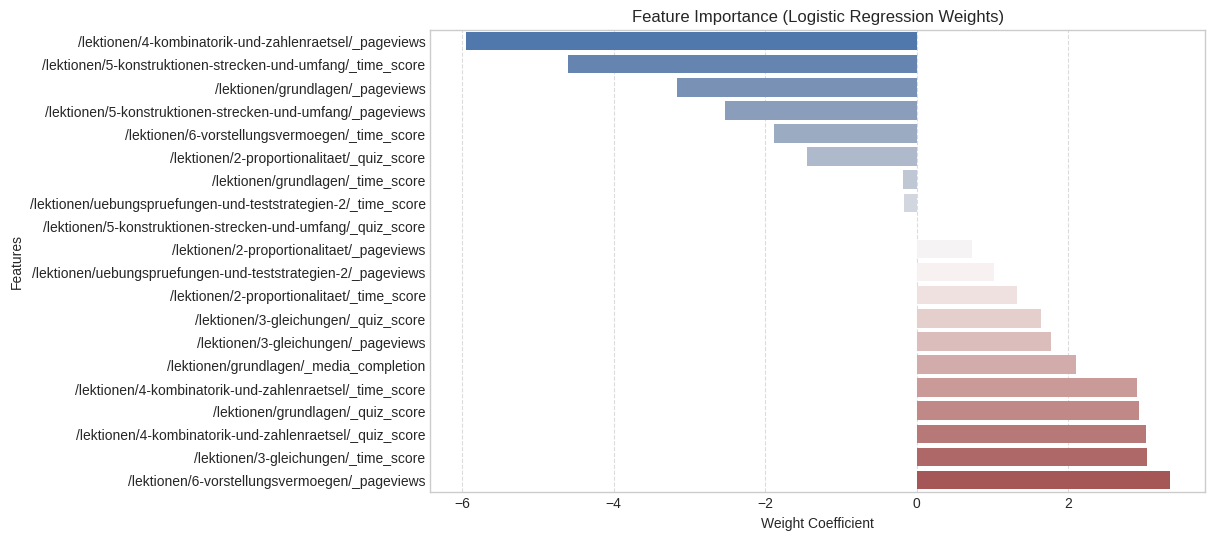

                                              Feature    Weight  \
7   /lektionen/4-kombinatorik-und-zahlenraetsel/_p... -5.952023   
15  /lektionen/5-konstruktionen-strecken-und-umfan... -4.595516   
10                   /lektionen/grundlagen/_pageviews -3.167109   
8   /lektionen/5-konstruktionen-strecken-und-umfan... -2.525057   
16     /lektionen/6-vorstellungsvermoegen/_time_score -1.884651   
0          /lektionen/2-proportionalitaet/_quiz_score -1.451732   
17                  /lektionen/grundlagen/_time_score -0.180402   
18  /lektionen/uebungspruefungen-und-teststrategie... -0.164852   
3   /lektionen/5-konstruktionen-strecken-und-umfan...  0.000000   
5           /lektionen/2-proportionalitaet/_pageviews  0.733066   
11  /lektionen/uebungspruefungen-und-teststrategie...  1.015761   
12         /lektionen/2-proportionalitaet/_time_score  1.316560   
1                /lektionen/3-gleichungen/_quiz_score  1.644747   
6                 /lektionen/3-gleichungen/_pageviews  1.77228

In [63]:
model_log_df = pd.merge(features, lang_df, on='user_id', how='inner')

X_log = model_log_df.drop(columns=['user_id', 'passed_exam'])

y_log = model_log_df['passed_exam']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.3, random_state=42) # random_state to get the same values each time we run it

scaler_log = StandardScaler()

X_train_final_log = pd.DataFrame(
    scaler_log.fit_transform(X_train_log), 
    columns=X_train_log.columns, 
    index=X_train_log.index
)
X_test_final_log = pd.DataFrame(
    scaler_log.transform(X_test_log), 
    columns=X_test_log.columns, 
    index=X_test_log.index
)
model_log = LogisticRegression(C=10, penalty='elasticnet', solver='saga', l1_ratio=0.9, class_weight='balanced', max_iter=5000, random_state=42)

model_log.fit(X_train_final_log, y_train_log)
pred_log = model_log.predict(X_test_final_log)

weights_df = pd.DataFrame({
    'Feature': X_train_log.columns,
    'Weight': model_log.coef_[0],
    'Absolute Weight': np.abs(model_log.coef_[0])
})

plt.figure(figsize=(10, 6))
weights_df_sorted = weights_df.sort_values(by='Weight')
weights_df_sorted.to_csv('model_feature_weights.csv', index=False)

sns.barplot(
    x='Weight', 
    y='Feature', 
    data=weights_df_sorted,
    hue='Feature', 
    palette='vlag',
    legend=False
)

plt.title('Feature Importance (Logistic Regression Weights)')
plt.xlabel('Weight Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('log_weights.png', dpi=300, bbox_inches='tight')
plt.show()
print(weights_df_sorted)

### Neural Network

In [64]:
# ─────────────────────────────────────────────
# 0. Reproducibility
# ─────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
 
# ─────────────────────────────────────────────
# 1. Data preparation  (your existing split)
# ─────────────────────────────────────────────
model_df = pd.merge(features, lang_df, on='user_id', how='inner')
X = model_df.drop(columns=['user_id', 'passed_exam'])
y = model_df['passed_exam']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
 
# ── Convert to PyTorch tensors ──────────────────────────────────────────────
def to_tensor(df_or_series, dtype=torch.float32):
    arr = df_or_series.values if hasattr(df_or_series, "values") else np.array(df_or_series)
    return torch.tensor(arr, dtype=dtype)
 
X_train_t = to_tensor(X_train)
X_test_t  = to_tensor(X_test)
y_train_t = to_tensor(y_train).unsqueeze(1)   # shape (N, 1)
y_test_t  = to_tensor(y_test).unsqueeze(1)
 
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)
 
# Batch size: small batches help generalisation on sparse data
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
 
# ─────────────────────────────────────────────
# 2. Model definition
# ─────────────────────────────────────────────
INPUT_DIM = X_train.shape[1]
 
# ─────────────────────────────────────────────
# 2. Model definition
# ─────────────────────────────────────────────
class BinaryClassifierLogits(nn.Module):
    def __init__(self, input_dim: int = INPUT_DIM, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
 
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(dropout),
 
            nn.Linear(16, 1),   # raw logits — sigmoid applied inside loss / at predict time
        )
 
    def forward(self, x):
        return self.net(x)
 
    def predict_proba(self, x):
        return torch.sigmoid(self.forward(x))
 
    def predict(self, x, threshold=0.5):
        return (self.predict_proba(x) >= threshold).long()
 
 
model = BinaryClassifierLogits()
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
 
# ─────────────────────────────────────────────
# 3. Loss, optimiser, scheduler
# ─────────────────────────────────────────────
# Class imbalance: compute pos_weight = #neg / #pos
n_pos = y_train_t.sum().item()
n_neg = len(y_train_t) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)
 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
 
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# ReduceLROnPlateau: halve LR if validation loss stalls for 10 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10)
 
# ─────────────────────────────────────────────
# 4. Training loop
# ─────────────────────────────────────────────
EPOCHS = 35
 
train_losses, val_losses = [], []
 
for epoch in range(1, EPOCHS + 1):
    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(Xb)
    train_losses.append(epoch_loss / len(train_ds))
 
    # ── validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in test_loader:
            logits = model(Xb)
            val_loss += criterion(logits, yb).item() * len(Xb)
    val_losses.append(val_loss / len(test_ds))
 
    scheduler.step(val_losses[-1])
 
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss:   {val_losses[-1]:.4f}")
 
# ─────────────────────────────────────────────
# 5. Evaluation helper
# ─────────────────────────────────────────────
def evaluate(loader, split_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds = model.predict(Xb).squeeze(1)
            all_preds.extend(preds.tolist())
            all_labels.extend(yb.squeeze(1).long().tolist())
 
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds)
 
    print(f"\n{'─'*40}")
    print(f"{split_name} Results")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"{'─'*40}")
    return acc, prec, rec, cm, all_labels, all_preds

BinaryClassifierLogits(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

Trainable parameters: 1,313
Epoch   1/35 | Train Loss: 1.3127 | Val Loss:   1.3159
Epoch  10/35 | Train Loss: 1.2146 | Val Loss:   1.3019
Epoch  20/35 | Train Loss: 1.0943 | Val Loss:   1.3037
Epoch  30/35 | Train Loss: 1.0947 | Val Loss:   1.3153


## Model Evaluation

### Logistic Regression

Accuracy: 76.92%
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        23
           1       0.00      0.00      0.00         3

    accuracy                           0.77        26
   macro avg       0.43      0.43      0.43        26
weighted avg       0.77      0.77      0.77        26



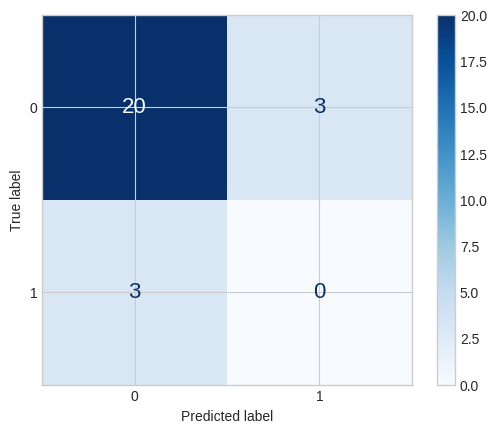

In [65]:
# Test set evaluation
accuracy = accuracy_score(y_test_log, pred_log)
print(f"Accuracy: {accuracy:.2%}")
report = classification_report(y_test_log, pred_log)
print(report)
matrix = confusion_matrix(y_test_log, pred_log)
matrix_display = ConfusionMatrixDisplay(matrix)
matrix_display.plot(cmap='Blues', text_kw={'size': 16})

Accuracy: 91.53%
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.55      1.00      0.71         6

    accuracy                           0.92        59
   macro avg       0.77      0.95      0.83        59
weighted avg       0.95      0.92      0.93        59



/home/arlakhian/School/Machine_Learning_for_Behavioral_Data/DKL-ML4BD/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


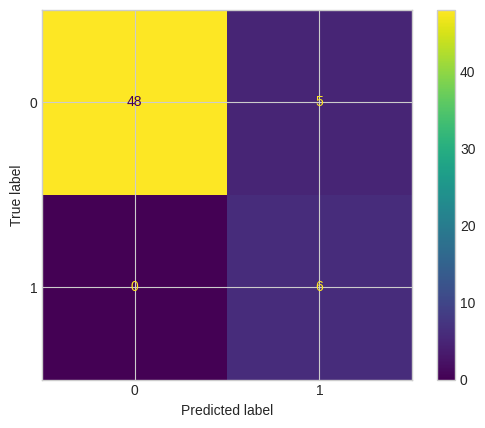

In [66]:
# Train set evaluation
model_log.fit(X_train_log, y_train_log)
train_pred_log = model_log.predict(X_train_log)

accuracy = accuracy_score(y_train_log, train_pred_log)
print(f"Accuracy: {accuracy:.2%}")
report = classification_report(y_train_log, train_pred_log)
print(report)
matrix = confusion_matrix(y_train_log, train_pred_log)
matrix_display = ConfusionMatrixDisplay(matrix)
matrix_display.plot()

### Neural Network


────────────────────────────────────────
TRAIN Results
  Accuracy : 0.2203
  Precision: 0.1154
  Recall   : 1.0000
────────────────────────────────────────

────────────────────────────────────────
TEST  Results
  Accuracy : 0.2308
  Precision: 0.1304
  Recall   : 1.0000
────────────────────────────────────────


/tmp/ipykernel_26415/2049434437.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


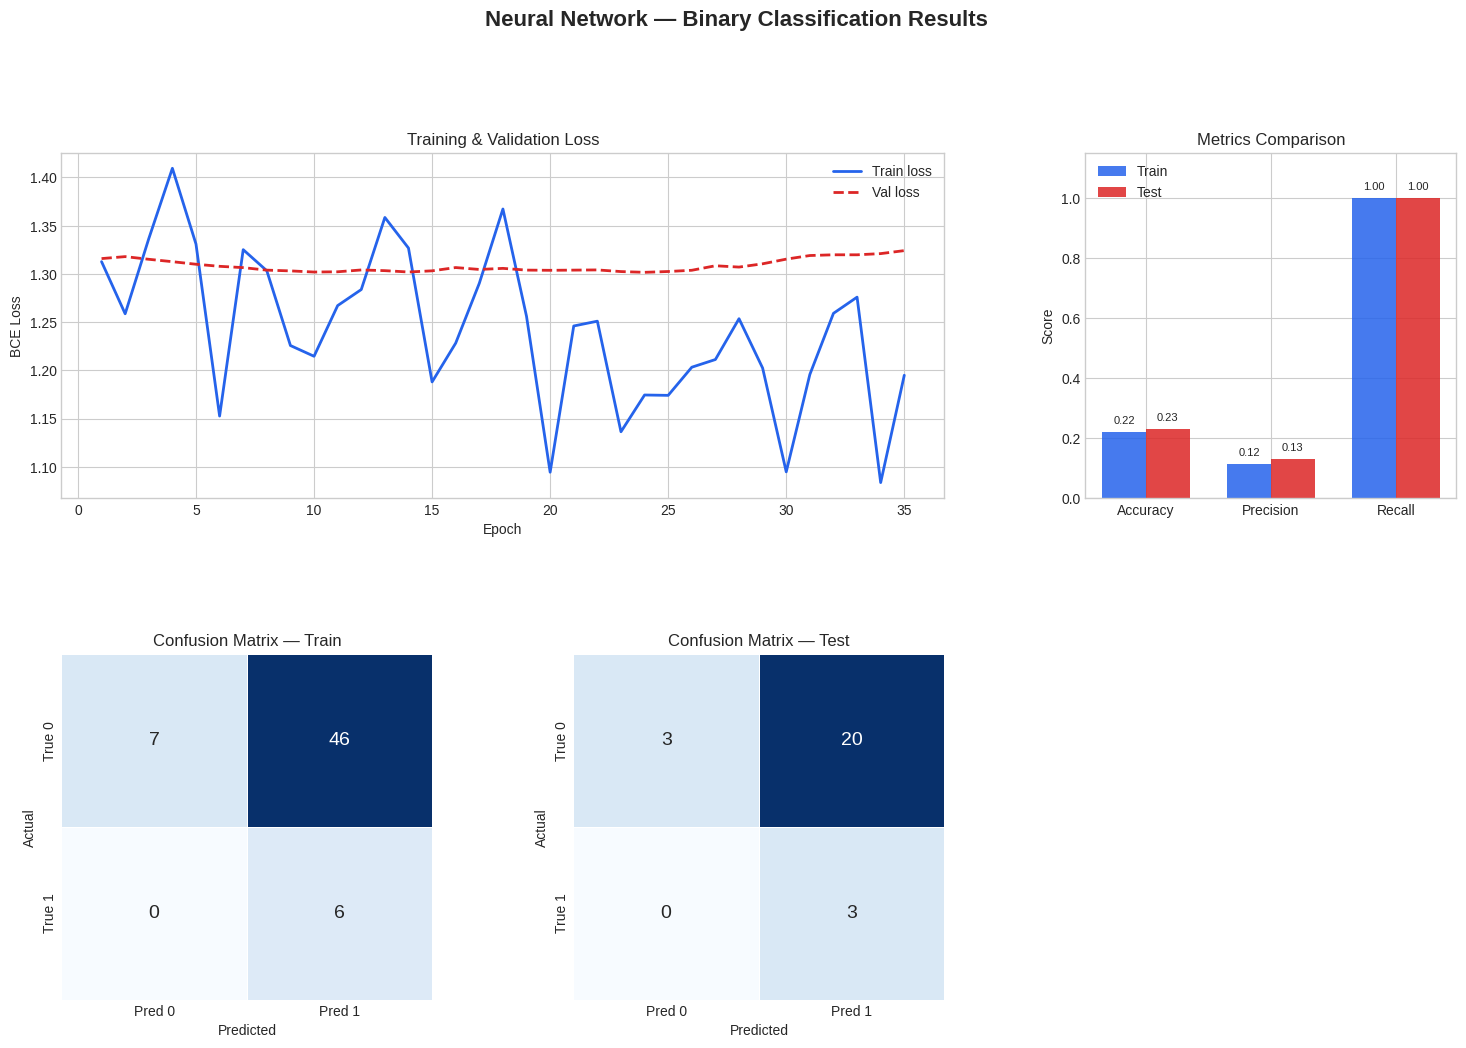


✓ Plot saved to nn_results.png


In [67]:
train_acc, train_prec, train_rec, train_cm, train_labels, train_preds = evaluate(train_loader, "TRAIN")
test_acc,  test_prec,  test_rec,  test_cm,  test_labels,  test_preds  = evaluate(test_loader,  "TEST ")

# ─────────────────────────────────────────────
# 6. Visualisation
# ─────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Neural Network — Binary Classification Results", fontsize=16, fontweight="bold", y=1.01)
 
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── (A) Loss curve ─────────────────────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, :2])
epochs_range = range(1, EPOCHS + 1)
ax_loss.plot(epochs_range, train_losses, label="Train loss", linewidth=2, color="#2563eb")
ax_loss.plot(epochs_range, val_losses,   label="Val loss",   linewidth=2, color="#dc2626", linestyle="--")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("BCE Loss")
ax_loss.set_title("Training & Validation Loss")
ax_loss.legend()
 
# ── (B) Metrics bar chart ──────────────────────────────────────────────────
ax_metrics = fig.add_subplot(gs[0, 2])
metrics_labels = ["Accuracy", "Precision", "Recall"]
train_vals = [train_acc, train_prec, train_rec]
test_vals  = [test_acc,  test_prec,  test_rec]
x = np.arange(len(metrics_labels))
width = 0.35
bars1 = ax_metrics.bar(x - width/2, train_vals, width, label="Train", color="#2563eb", alpha=0.85)
bars2 = ax_metrics.bar(x + width/2, test_vals,  width, label="Test",  color="#dc2626", alpha=0.85)
ax_metrics.set_ylim(0, 1.15)
ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels(metrics_labels)
ax_metrics.set_ylabel("Score")
ax_metrics.set_title("Metrics Comparison")
ax_metrics.legend()
for bar in [*bars1, *bars2]:
    ax_metrics.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.2f}",
        ha="center", va="bottom", fontsize=8
    )

# ── (C) Confusion matrices ─────────────────────────────────────────────────
for col, (cm, title) in enumerate(
    [(train_cm, "Confusion Matrix — Train"), (test_cm, "Confusion Matrix — Test")]
):
    ax_cm = fig.add_subplot(gs[1, col])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
        ax=ax_cm, linewidths=0.5, cbar=False,
        annot_kws={"size": 14}
    )
    ax_cm.set_title(title)
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("Actual")
 
plt.tight_layout()
plt.savefig("nn_results.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Plot saved to nn_results.png")

## Explainability
In this section, we utilize a DiCE model to answer our second research question.
The goal here is to understand a failing student has to do in order to get classified as a passing student by the model. Using a DiCE model, we generate counterfactuals example that tell us the minimal change a student has to make in order to succeed.

In [68]:
# Copy the training set of the Logistic Regression model
train_dice_log = X_train_log.copy()
train_dice_log["passed_exam"] = y_train_log.values
continuous_features = X_train_log.columns.tolist()

# Initialize the DiCE Data object
d_log = dice_ml.Data(
    dataframe=train_dice_log,
    continuous_features=continuous_features,
    outcome_name='passed_exam'
)

# DiCE ML model
m_log = dice_ml.Model(model=model_log, backend='sklearn')

# DiCE explanation instance
exp_log = dice_ml.Dice(d_log,m_log)

# Get only failing students
failing_indices_log = y_test_log[y_test_log == 0].index.tolist()

# A counter for the number of time each feature is changed
feature_frequency_log = Counter()

# A dictionary to store by how much each feature has been changed each time
feature_differences_log = defaultdict(list)

# Traverse all of the failing students in the test set and use DiCE on them
for failing in failing_indices_log:
    # Get the features associated with the target
    query_instance = X_test_log.loc[[failing]]

    # Generate the counterfactuals for the failing student
    dice_exp = exp_log.generate_counterfactuals(query_instance, total_CFs=5, desired_class=1, features_to_vary='all', random_seed=42)

    # Extract the generated counterfactuals
    conterfactuals_list = dice_exp.cf_examples_list[0].final_cfs_df

    for counterfactuals in conterfactuals_list.iterrows():
        # Get a Serie of the original values for the student
        original_values = query_instance.iloc[0]

        # Get a Serie of the counterfactuals values and remove the target
        counterfactuals_values = counterfactuals[1].drop('passed_exam')

        for feature in X_test_log.columns:
            diff = counterfactuals_values[feature] - original_values[feature]

            # If a feature was changed, track it
            if abs(diff) > 0:
                # Add 1 to the frequency
                feature_frequency_log[feature] += 1

                # Add the difference to the list of differences of the feature
                feature_differences_log[feature].append(diff)

# Put everything together
final_feature_diff_log = []
for feature in X_test_log.columns:
    count = feature_frequency_log[feature]
    diffs = feature_differences_log[feature]
    avg_diff = np.mean(diffs) if count > 0 else 0
    final_feature_diff_log.append({
        'Feature': feature,
        'Frequency': count,
        'Average_Difference': avg_diff
    })

# Put it in a DataFrame and display
df_summary = pd.DataFrame(final_feature_diff_log).sort_values(by='Frequency', ascending=False)
df_summary.to_csv('DiCE_model_conterfactuals.csv', index=False)
display(df_summary)

100%|██████████| 1/1 [00:00<00:00,  6.24it/s]


,Feature,Frequency,Average_Difference
19,/lektionen/grundlagen/_media_completion,46,0.854239
13,/lektionen/3-gleichungen/_time_score,28,0.671416
9,/lektionen/6-vorstellungsvermoegen/_pageviews,18,0.807407
7,/lektionen/4-kombinatorik-und-zahlenraetsel/_p...,16,-0.714063
10,/lektionen/grundlagen/_pageviews,13,-0.544231
14,/lektionen/4-kombinatorik-und-zahlenraetsel/_t...,12,0.816747
2,/lektionen/4-kombinatorik-und-zahlenraetsel/_q...,12,0.559325
1,/lektionen/3-gleichungen/_quiz_score,12,0.705293
3,/lektionen/5-konstruktionen-strecken-und-umfan...,11,0.580664
15,/lektionen/5-konstruktionen-strecken-und-umfan...,9,-0.465836


In [69]:
def predict_fn(x):
    """
    Function to change the output of the NN model from binary to probabilities.
    """
    model.eval()
    # Convert input data to a numpy array first, then to a torch tensor
    x_arr = np.asarray(x)
        
    x_tensor = torch.tensor(x_arr, dtype=torch.float32)
    
    with torch.no_grad():
        # Get probabilities for class success
        prob_1 = torch.sigmoid(model(x_tensor)).numpy()
        
    # Array containing both classes's probability to feed DiCE
    prob_0 = 1.0 - prob_1
    return np.c_[prob_0, prob_1]

# Copy the training set of the Neural Network
train_dice_nn = X_train.copy()
train_dice_nn["passed_exam"] = y_train.values
continuous_features = X_train.columns.tolist()

# Initialize the DiCE Data object
d_nn = dice_ml.Data(
    dataframe=train_dice_nn,
    continuous_features=continuous_features,
    outcome_name='passed_exam'
)

# Change the prediction function to output probabilities instead of a pass/fail prediction
model.predict_proba = predict_fn
# DiCE ML model using custom prediction function wrapper
m_nn = dice_ml.Model(model=model, backend='sklearn')

# DiCE explanation instance
exp_nn = dice_ml.Dice(d_nn, m_nn)

# Get only failing students
failing_indices_nn = y_test[y_test == 0].index.tolist()

# A counter for the number of times each feature is changed
feature_frequency_nn = Counter()

# A dictionary to store by how much each feature has been changed each time
feature_differences_nn = defaultdict(list)

# Traverse all of the failing students in the test set and use DiCE on them
for failing in failing_indices_nn:
    # Get the features associated with the target
    query_instance = X_test.loc[[failing]]

    # Generate the counterfactuals for the failing student
    dice_exp = exp_nn.generate_counterfactuals(query_instance, total_CFs=5, desired_class=1, features_to_vary='all', random_seed=42)

    # Extract the generated counterfactuals dataframe
    counterfactuals_list = dice_exp.cf_examples_list[0].final_cfs_df
    
    if counterfactuals_list is None:
        continue

    for counterfactual in counterfactuals_list.iterrows():
        # Get a Series of the original values for the student
        original_values = query_instance.iloc[0]

        # Get a Series of the counterfactual values and remove the target
        counterfactuals_values = counterfactual[1].drop('passed_exam')

        for feature in X_test.columns:
            diff = counterfactuals_values[feature] - original_values[feature]

            # If a feature was changed, track it
            if abs(diff) > 0:
                # Add 1 to the frequency
                feature_frequency_nn[feature] += 1

                # Add the difference to the list of differences of the feature
                feature_differences_nn[feature].append(diff)

# Put everything together
final_feature_diff_nn = []
for feature in X_test.columns:
    count = feature_frequency_nn[feature]
    diffs = feature_differences_nn[feature]
    avg_diff = np.mean(diffs) if count > 0 else 0
    final_feature_diff_nn.append({
        'Feature': feature,
        'Frequency': count,
        'Average_Difference': avg_diff
    })

# Put it in a DataFrame and display
df_summary_nn = pd.DataFrame(final_feature_diff_nn).sort_values(by='Frequency', ascending=False)
df_summary_nn.to_csv('DiCE_NN_model_counterfactuals.csv', index=False)
display(df_summary_nn)

100%|██████████| 1/1 [00:00<00:00,  7.17it/s]


,Feature,Frequency,Average_Difference
2,/lektionen/4-kombinatorik-und-zahlenraetsel/_q...,17,0.363259
16,/lektionen/6-vorstellungsvermoegen/_time_score,17,0.145260
14,/lektionen/4-kombinatorik-und-zahlenraetsel/_t...,16,0.083858
7,/lektionen/4-kombinatorik-und-zahlenraetsel/_p...,13,-0.048077
11,/lektionen/uebungspruefungen-und-teststrategie...,13,0.015385
9,/lektionen/6-vorstellungsvermoegen/_pageviews,12,0.491667
3,/lektionen/5-konstruktionen-strecken-und-umfan...,12,0.700463
19,/lektionen/grundlagen/_media_completion,12,0.377182
18,/lektionen/uebungspruefungen-und-teststrategie...,10,0.360000
12,/lektionen/2-proportionalitaet/_time_score,10,-0.081341
